## Trust Game 2026 
Model based results: Mann-Whittney U statistic of group differences and plots

In [ ]:
# Preparation
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

df_full=pd.read_csv("April2025_full_model_merged.csv")

In [ ]:
# selecting model-based outcomes of primary interest
columns_to_test = ['Trustee ToM', 'Trustee Planning Steps', 'Trustee Guilt Parameter',
                   'Trustee Irritability', 'Trustee Irritation Belief']

# Perform the Mann-Whitney U test for each outcome
results = {}

for column in columns_to_test:
    # Separate the data by 'group'
    group1 = df_full[df_full["group"] == df_full["group"].unique()[0]][column]
    group2 = df_full[df_full["group"] == df_full["group"].unique()[1]][column]
    
    # Perform the Mann-Whitney U test
    stat, p_value = stats.mannwhitneyu(group1, group2)
    
    # Store and print the result
    results[column] = {"U-statistic": stat, "p-value": p_value}
    print(f"{column} - U-statistic: {stat}, p-value: {p_value}")


Trustee ToM - U-statistic: 926.0, p-value: 0.02866685698925873
Trustee Planning Steps - U-statistic: 1120.0, p-value: 0.5285647185014302
Trustee Guilt Parameter - U-statistic: 864.0, p-value: 0.01021818383673239
Trustee Irritability - U-statistic: 1512.5, p-value: 0.0028563779485904672
Trustee Irritation Belief - U-statistic: 1005.5, p-value: 0.1374436009828224


/var/folders/z2/rjz3w2nd3b9d20ymsr0h0x6c0000gp/T/ipykernel_31484/1180687525.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/var/folders/z2/rjz3w2nd3b9d20ymsr0h0x6c0000gp/T/ipykernel_31484/1180687525.py:31: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='count'` for the same effect.
  ax = sns.violinplot(


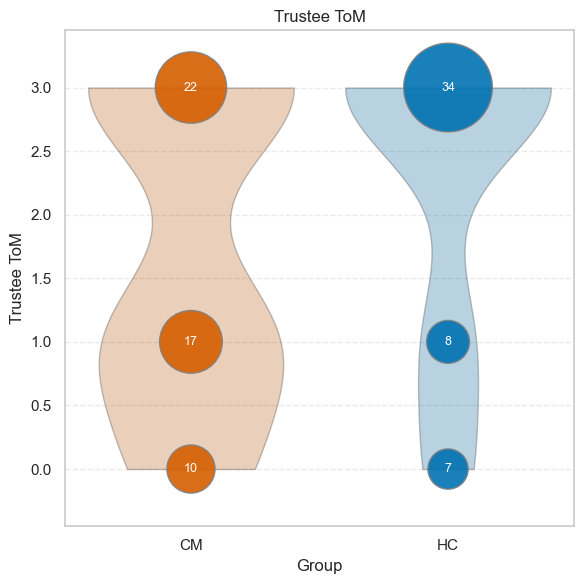

/var/folders/z2/rjz3w2nd3b9d20ymsr0h0x6c0000gp/T/ipykernel_31484/1180687525.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/var/folders/z2/rjz3w2nd3b9d20ymsr0h0x6c0000gp/T/ipykernel_31484/1180687525.py:31: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='count'` for the same effect.
  ax = sns.violinplot(


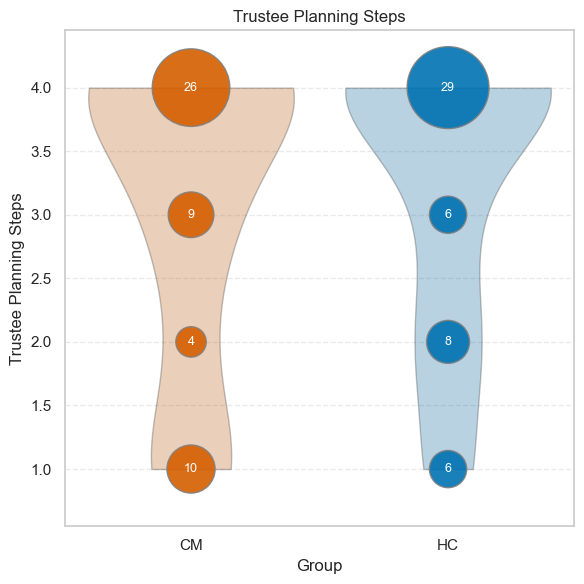

/var/folders/z2/rjz3w2nd3b9d20ymsr0h0x6c0000gp/T/ipykernel_31484/1180687525.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/var/folders/z2/rjz3w2nd3b9d20ymsr0h0x6c0000gp/T/ipykernel_31484/1180687525.py:31: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='count'` for the same effect.
  ax = sns.violinplot(


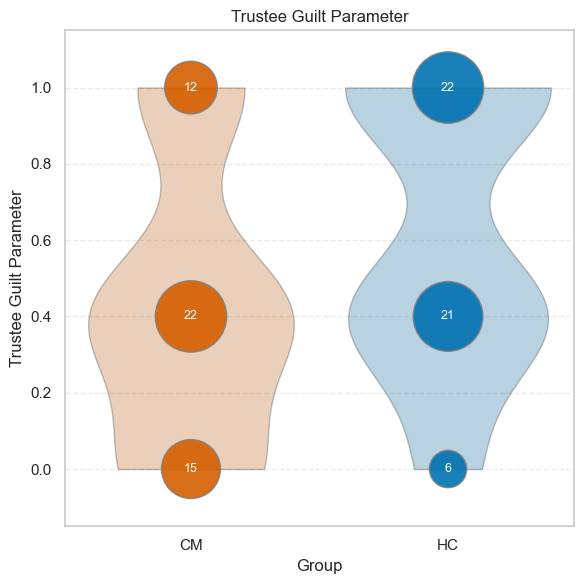

/var/folders/z2/rjz3w2nd3b9d20ymsr0h0x6c0000gp/T/ipykernel_31484/1180687525.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/var/folders/z2/rjz3w2nd3b9d20ymsr0h0x6c0000gp/T/ipykernel_31484/1180687525.py:31: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='count'` for the same effect.
  ax = sns.violinplot(


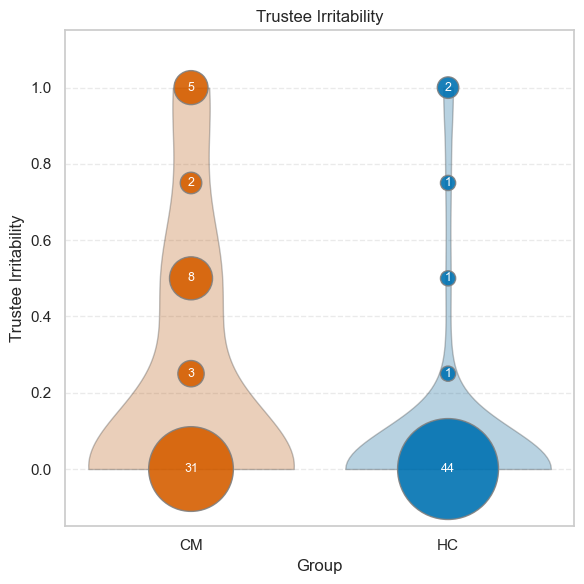

/var/folders/z2/rjz3w2nd3b9d20ymsr0h0x6c0000gp/T/ipykernel_31484/1180687525.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/var/folders/z2/rjz3w2nd3b9d20ymsr0h0x6c0000gp/T/ipykernel_31484/1180687525.py:31: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='count'` for the same effect.
  ax = sns.violinplot(


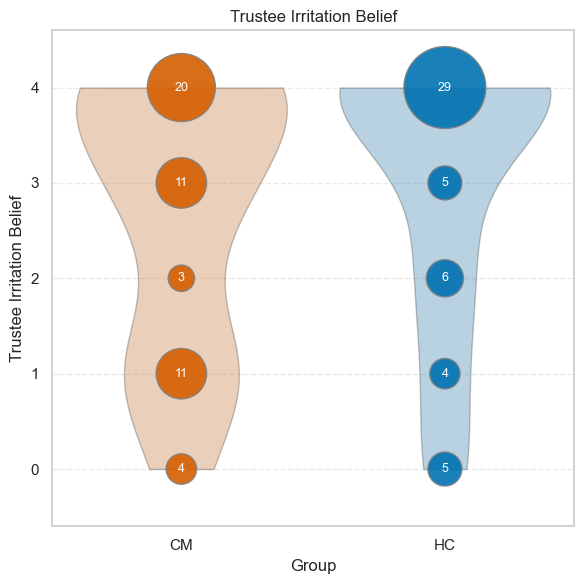

In [ ]:
# Set seaborn style
sns.set(style='whitegrid')

# Colorblind-friendly group colors
group_colors = {
    'HC': '#0072B2',     # Blue
    'CM': '#D55E00',     # Vermillion
}

# Bubble size scale
scale = 120

# Columns you want to plot
columns_to_plot = [
    'Trustee ToM',
    'Trustee Planning Steps',
    'Trustee Guilt Parameter',
    'Trustee Irritability',
    'Trustee Irritation Belief'
]

# Loop through each parameter and make the plot
for col in columns_to_plot:
    plt.figure(figsize=(6, 6))
    
    # Draw violinplot and capture axis
    ax = sns.violinplot(
        data=df_full,
        x='group',
        y=col,
        palette=group_colors,
        cut=0,
        scale='count',
        inner=None,
        linewidth=1,
        alpha=0.3
    )

    # Get actual x-axis tick positions used by seaborn
    x_positions = {tick.get_text(): tick.get_position()[0] for tick in ax.get_xticklabels()}

    # Collect all y values to set y-limits
    all_y = []

    # Overlay bubbles
    for group, color in group_colors.items():
        group_df = df_full[df_full['group'] == group]
        value_counts = group_df[col].value_counts().sort_index()

        y = value_counts.index
        sizes = value_counts.values
        x = [x_positions[group]] * len(y)
        all_y.extend(y)

        plt.scatter(x, y, s=sizes * scale, alpha=0.9, color=color, edgecolors='grey')#, zorder=3)

        # Annotate counts
        for xi, yi, si in zip(x, y, sizes):
            plt.text(xi, yi, str(si), ha='center', va='center', fontsize=9, color='white')#, weight='bold', zorder=4)

    # Format axes
    plt.xlabel('Group')
    plt.ylabel(col)
    plt.title(f'{col}')
    plt.grid(axis='y', linestyle='--', alpha=0.4)

    # Adjust y-limits to fit bubbles
    y_range = max(all_y) - min(all_y)
    y_pad = y_range * 0.15 if y_range != 0 else 1
    plt.ylim(min(all_y) - y_pad, max(all_y) + y_pad)

    plt.tight_layout()
    plt.show()
